# Vježbe 14 — XAI: Objašnjivi AI (SHAP + LIME)
**Predmet:** Rudarenje podataka — I. godina — II ciklus — Softversko inženjerstvo  
**Asistent:** ass. mr. Narcisa Hadžajlić  
**Datum:** 25.5.2026.

---

## Šta smo do sada naučili
- **Vježbe 8–9:** MLP, regularizacija
- **Vježbe 10–11:** CNN, Transfer Learning
- **Vježbe 12:** Vremenske serije, LSTM
- **Vježbe 13:** GAN, cGAN — generativni modeli

## Novi problem: "Crna kutija"

Sve mreže koje smo trenirali su **crne kutije** koje daju odgovor, ali ne objašnjavaju zašto.

U praksi to stvara ozbiljne probleme, na primjer:
- **Medicina:** Model kaže "pacijent ima visok rizik", a doktor mora znati zašto da bi liječio
- **Bankarstvo:** Model odbija kredit, a zakon zahtijeva objašnjenje
- **Pravosuđe:** Model predviđa recidivizam, sudija mora razumjeti osnovu odluke
- **Inženjering:** Model detektuje grešku u sistemu, inženjer mora znati koji senzor

**XAI (Explainable AI)** je skup metoda koji otvaraju crnu kutiju i govore:
*"Ovaj feature je doprinijeo predikciji toliko, ovaj je smanjio, ovaj nije bio važan."*

### Plan:
1. Globalna vs. lokalna objašnjenja
2. SHAP: teorijski utemeljeno objašnjenje
3. LIME: lokalna aproksimacija
4. XAI na medicinskom datasetu: gdje je razlika bitna
5. SHAP za neuralnu mrežu
6. Zadatak 4 boda

---
## 1. Globalna vs. Lokalna objašnjenja

**Globalno objašnjenje**: koji su featuri općenito važni za model?
- "Alkohol je najvažniji faktor za kvalitetu vina u ovom modelu"
- Korisno za razumijevanje modela u cjelini i debugging

**Lokalno objašnjenje**: zašto je model donio OVU konkretnu odluku?
- "Za ovog pacijenta, visoki krvni tlak je povećao rizik za 34%, a dob za 21%"
- Korisno za konkretne odluke i regulatorne zahtjeve

| Metoda | Tip | Pristup |
|---|---|---|
| **SHAP** | Globalno + Lokalno | Teorija igara — pravedna raspodjela doprinosa |
| **LIME** | Lokalno | Lokalna linearna aproksimacija |
| Feature Importance | Globalno | Wgrađeno u tree modele |
| Saliency Maps | Lokalno | Gradijenti za neuronske mreže na slikama |

### SHAP Intuicija: Shapley vrijednosti iz teorije igara

Zamislite tim od 4 igrača koji zajedno osvoje nagradu. Koliko svaki zaslužuje?
Shapley vrijednost: za svakog igrača, izračunaj prosječni doprinos u **svim mogućim kombinacijama** tima.

U ML: "igrači" su featuri, "nagrada" je predikcija. SHAP kaže koliko je svaki feature **pravedno** doprinio predikciji.

**Ključno svojstvo:** SHAP vrijednosti se sabiraju na predikciju:
```
predikcija = bazna_vrijednost + SHAP(feature1) + SHAP(feature2) + ... + SHAP(featureN)
```

### LIME Intuicija: "Šta se desi kad malo promijenim input?"

Za jedan konkretan primjer:
1. Generiraj mnogo smetnji (malo izmijenjenih verzija tog primjera)
2. Pusti ih kroz crnu kutiju: dobij predikcije
3. Nauči **jednostavan linearni model** koji aproksimira ponašanje crne kutije lokalno
4. Koeficijenti tog linearnog modela = objašnjenje

---
## 2. Instalacija i importi

In [1]:
# Instalacija biblioteka (pokrenite jednom)
import subprocess, sys
for paket in ['shap', 'lime']:
    try:
        __import__(paket)
        print(f"{paket} — već instaliran")
    except ImportError:
        print(f"Instaliram {paket}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', paket, '-q'])
        print(f"{paket} — instaliran!")

Instaliram shap...
shap — instaliran!
Instaliram lime...
lime — instaliran!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML modeli
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.datasets import load_breast_cancer

# XAI biblioteke
import shap
from lime import lime_tabular

# Neuralna mreža
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel('ERROR')

np.random.seed(42)
tf.random.set_seed(42)

shap.initjs()  # inicijalizacija SHAP JavaScript vizualizacija
print(f"SHAP verzija: {shap.__version__}")
print("Sve uvezeno!")

SHAP verzija: 0.51.0
Sve uvezeno!


---
## 3. Dataset — Breast Cancer (dijagnoza raka dojke)

Koristimo **Wisconsin Breast Cancer** dataset — 569 uzoraka, 30 numeričkih featuri (karakteristike ćelija tumora), binary target: maligno (1) ili benigno (0).

Ovo je namjerno odabran medicinski dataset jer **ovdje objašnjenje nije luksuz — ono je etička i zakonska obaveza.** Doktor ne smije reći pacijentu "algoritam kaže da je maligno" bez objašnjenja.

In [3]:
# Učitavanje dataseta
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target  # 0 = maligno, 1 = benigno

print("Breast Cancer Dataset:")
print(f"  Uzoraka:  {X.shape[0]}")
print(f"  Featuri:  {X.shape[1]}")
print(f"  Klase:    maligno={sum(y==0)}, benigno={sum(y==1)}")
print(f"\nFeaturi: {list(cancer.feature_names[:10])} ...")
X.describe().round(2)

Breast Cancer Dataset:
  Uzoraka:  569
  Featuri:  30
  Klase:    maligno=212, benigno=357

Featuri: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension')] ...


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


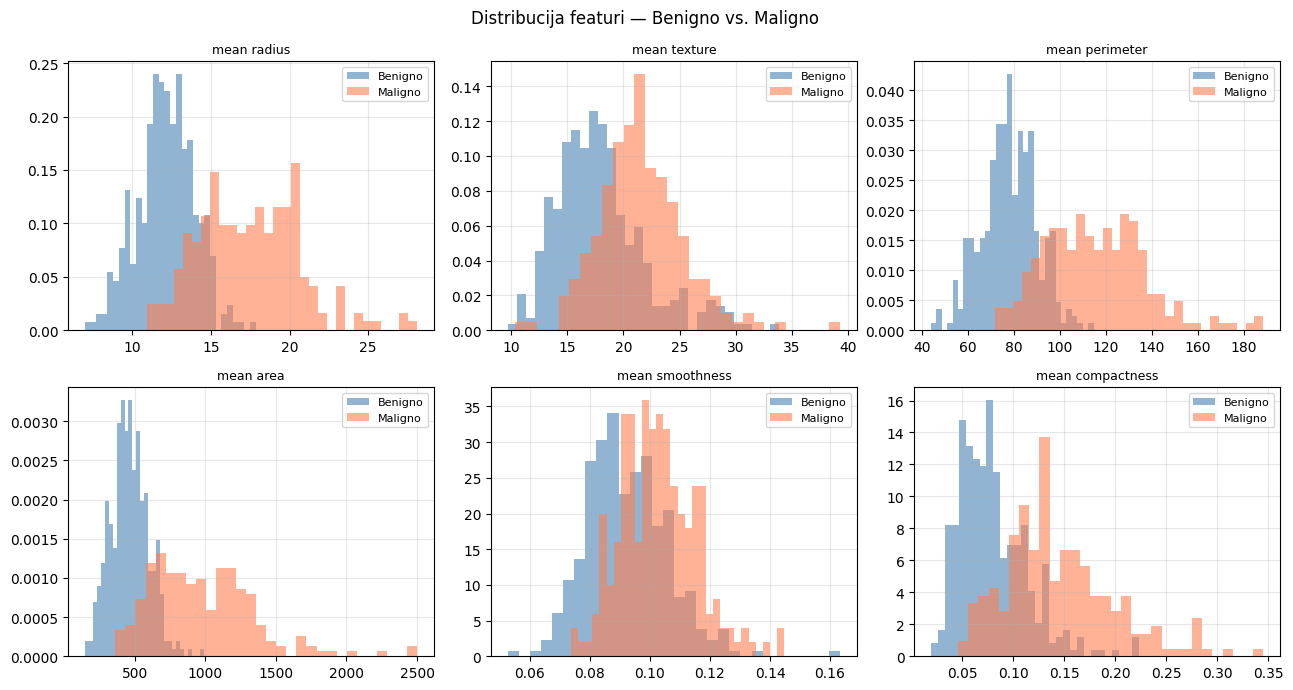

Vidimo: neki featuri dobro razdvajaju klase, neki se preklapaju.
SHAP će nam reći koji su najvažniji ZA NAŠ MODEL.


In [4]:
# Vizualizacija: distribucija prvih 6 featuri po klasi
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feature in zip(axes.flat, cancer.feature_names[:6]):
    benigno  = X[feature][y == 1]
    maligno  = X[feature][y == 0]
    ax.hist(benigno,  bins=30, alpha=0.6, color='steelblue', label='Benigno', density=True)
    ax.hist(maligno,  bins=30, alpha=0.6, color='coral',     label='Maligno', density=True)
    ax.set_title(feature, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Distribucija featuri — Benigno vs. Maligno', fontsize=12)
plt.tight_layout()
plt.show()

print("Vidimo: neki featuri dobro razdvajaju klase, neki se preklapaju.")
print("SHAP će nam reći koji su najvažniji ZA NAŠ MODEL.")

In [5]:
# Train/test split + skaliranje
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_s  = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=cancer.feature_names
)
X_test_s   = pd.DataFrame(
    scaler.transform(X_test),
    columns=cancer.feature_names
)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (455, 30), Test: (114, 30)


---
## 4. Trening modela

Treniramo **Random Forest** — odličan model za XAI demonstraciju jer je i sam po sebi interpretabilan (feature importance), ali SHAP ide dublje.

In [6]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)

y_pred_rf = rf.predict(X_test_s)
f1_rf     = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Random Forest — F1: {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Maligno', 'Benigno']))

# Gradient Boosting za usporedbu
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_s, y_train)
f1_gb = f1_score(y_test, gb.predict(X_test_s), average='weighted')
print(f"Gradient Boosting — F1: {f1_gb:.4f}")

Random Forest — F1: 0.9560
              precision    recall  f1-score   support

     Maligno       0.95      0.93      0.94        42
     Benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Gradient Boosting — F1: 0.9558


---
## 5. SHAP — Globalna objašnjenja

Počinjemo s globalnom slikom: koji su featuri **općenito** najvažniji za model?

In [7]:
# SHAP TreeExplainer — optimizovan za tree-based modele (RF, XGBoost, LightGBM)
# Mnogo brži od KernelExplainer
explainer    = shap.TreeExplainer(rf)
shap_values  = explainer.shap_values(X_test_s)

# shap_values je lista [klasa_0, klasa_1]
# Uzimamo klasu 1 (benigno) za vizualizaciju
shap_benigno = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP values shape: {shap_benigno.shape}")
print(f"  ← ({X_test_s.shape[0]} test uzoraka, {X_test_s.shape[1]} featuri)")
print(f"\nBazna vrijednost (expected value): {explainer.expected_value[1]:.4f}")
print(f"  ← Prosječna predikcija modela = polazna tačka za sva objašnjenja")

SHAP values shape: (114, 30, 2)
  ← (114 test uzoraka, 30 featuri)

Bazna vrijednost (expected value): 0.6245
  ← Prosječna predikcija modela = polazna tačka za sva objašnjenja


<Figure size 1000x800 with 0 Axes>

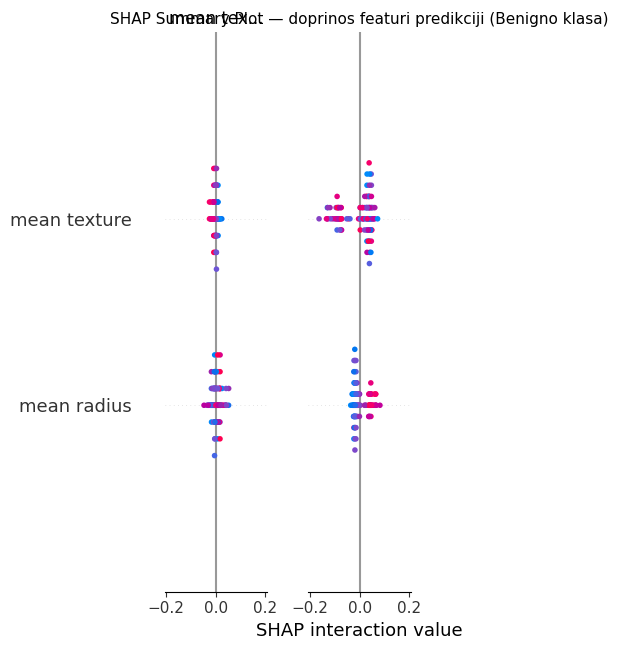

Kako čitati Summary Plot:
  Featuri poredani po globalnoj važnosti (gore = najvažniji)
  Svaka tačka = jedan test uzorak
  X > 0: feature POVEĆAVA vjerovatnoću benigno
  X < 0: feature SMANJUJE vjerovatnoću benigno (= povećava rizik maligno)
  Crvena tačka = visoka vrijednost featuri, Plava = niska


In [8]:
# Summary Plot — globalna važnost featuri
# Svaka tačka = jedan uzorak
# X osa = SHAP vrijednost (doprinos predikciji)
# Boja = vrijednost featuri (crvena=visoka, plava=niska)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_benigno,
    X_test_s,
    plot_type='dot',  # alternativa: 'bar' za jednostavniji prikaz
    show=False
)
plt.title('SHAP Summary Plot — doprinos featuri predikciji (Benigno klasa)', fontsize=11)
plt.tight_layout()
plt.show()

print("Kako čitati Summary Plot:")
print("  Featuri poredani po globalnoj važnosti (gore = najvažniji)")
print("  Svaka tačka = jedan test uzorak")
print("  X > 0: feature POVEĆAVA vjerovatnoću benigno")
print("  X < 0: feature SMANJUJE vjerovatnoću benigno (= povećava rizik maligno)")
print("  Crvena tačka = visoka vrijednost featuri, Plava = niska")

<Figure size 1000x600 with 0 Axes>

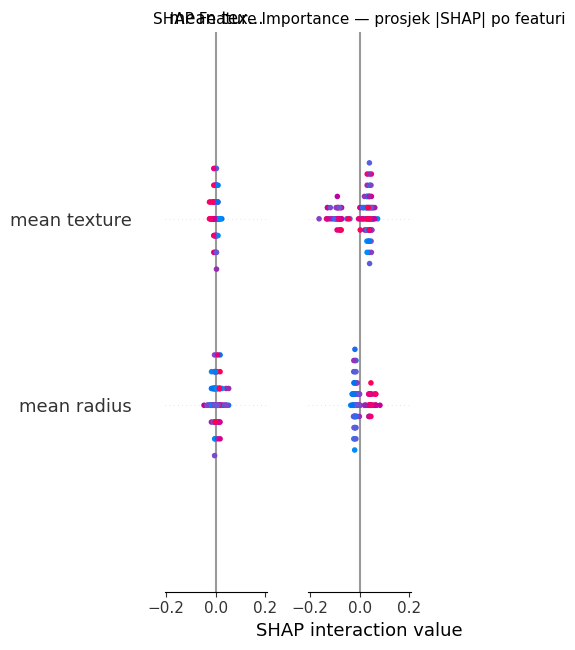

ValueError: Data must be 1-dimensional, got ndarray of shape (30, 2) instead

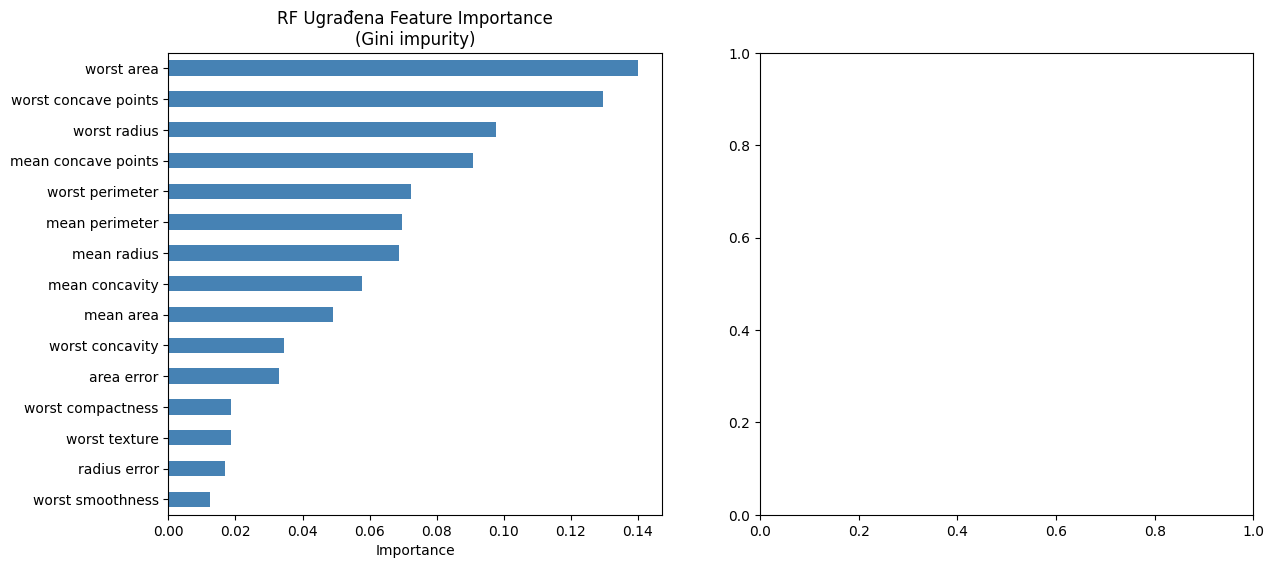

In [9]:
# Bar plot — jednostavniji prikaz globalne važnosti
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_benigno,
    X_test_s,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — prosjek |SHAP| po featuri', fontsize=11)
plt.tight_layout()
plt.show()

# Usporedba: SHAP vs. ugrađena RF feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# RF ugrađena feature importance
rf_importance = pd.Series(
    rf.feature_importances_, index=cancer.feature_names
).sort_values(ascending=True).tail(15)
rf_importance.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('RF Ugrađena Feature Importance\n(Gini impurity)')
ax1.set_xlabel('Importance')

# SHAP mean absolute values
shap_importance = pd.Series(
    np.abs(shap_benigno).mean(axis=0),
    index=cancer.feature_names
).sort_values(ascending=True).tail(15)
shap_importance.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('SHAP Feature Importance\n(mean |SHAP value|)')
ax2.set_xlabel('Mean |SHAP|')

plt.suptitle('RF Ugrađena vs. SHAP Importance — nisu uvijek iste!', fontsize=11)
plt.tight_layout()
plt.show()

print("Zašto se razlikuju? RF importance mjeri učestalost korištenja featuri")
print("u stablima. SHAP mjeri stvarni doprinos predikciji — preciznije i pouzdanije.")

---
## 6. SHAP — Lokalna objašnjenja (po uzorku)

Sada gledamo konkretne pacijente: zašto je model donio OVU odluku za OVOG pacijenta?

In [10]:
# Pronađi primjere: jedan tačno klasificiran benigno, jedan tačno maligno
y_pred_arr  = np.array(y_pred_rf)
y_test_arr  = np.array(y_test)

# Tačno predviđen benigno
tp_benigno_idx = np.where((y_pred_arr == 1) & (y_test_arr == 1))[0][0]
# Tačno predviđen maligno
tp_maligno_idx = np.where((y_pred_arr == 0) & (y_test_arr == 0))[0][0]

print(f"Pacijent A (benigno) — test indeks: {tp_benigno_idx}")
print(f"  Prava dijagnoza: {'Benigno' if y_test_arr[tp_benigno_idx] else 'Maligno'}")
print(f"  Predikcija:      {'Benigno' if y_pred_arr[tp_benigno_idx] else 'Maligno'}")
prob_a = rf.predict_proba(X_test_s.iloc[[tp_benigno_idx]])[0]
print(f"  Vjerovatnoće:    Maligno={prob_a[0]:.3f}, Benigno={prob_a[1]:.3f}")

print(f"\nPacijent B (maligno) — test indeks: {tp_maligno_idx}")
print(f"  Prava dijagnoza: {'Benigno' if y_test_arr[tp_maligno_idx] else 'Maligno'}")
print(f"  Predikcija:      {'Benigno' if y_pred_arr[tp_maligno_idx] else 'Maligno'}")
prob_b = rf.predict_proba(X_test_s.iloc[[tp_maligno_idx]])[0]
print(f"  Vjerovatnoće:    Maligno={prob_b[0]:.3f}, Benigno={prob_b[1]:.3f}")

Pacijent A (benigno) — test indeks: 1
  Prava dijagnoza: Benigno
  Predikcija:      Benigno
  Vjerovatnoće:    Maligno=0.000, Benigno=1.000

Pacijent B (maligno) — test indeks: 0
  Prava dijagnoza: Maligno
  Predikcija:      Maligno
  Vjerovatnoće:    Maligno=1.000, Benigno=0.000


In [12]:
# Waterfall plot — lokalno objašnjenje za jednog pacijenta
# Pokazuje kako se od bazne vrijednosti dolazi do konkretne predikcije

def waterfall_za_pacijenta(idx, naziv, shap_vals, X_df, explainer):
    shap_obj = shap.Explanation(
        values         = shap_vals[idx],
        base_values    = explainer.expected_value[1],
        data           = X_df.iloc[idx].values,
        feature_names  = list(X_df.columns)
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_obj, show=False)
    plt.title(f'SHAP Waterfall — {naziv}', fontsize=11)
    plt.tight_layout()
    plt.show()


print("Pacijent A — BENIGNO:")
waterfall_za_pacijenta(tp_benigno_idx, 'Pacijent A (Benigno)',
                       shap_benigno, X_test_s, explainer)

print("Pacijent B — MALIGNO:")
waterfall_za_pacijenta(tp_maligno_idx, 'Pacijent B (Maligno)',
                       shap_benigno, X_test_s, explainer)

print("Kako čitati Waterfall:")
print("  Polazna tačka (E[f(x)]): prosječna predikcija modela")
print("  Crvene trake (→ desno): feature povećava predikciju benigno")
print("  Plave trake (← lijevo): feature smanjuje predikciju benigno")
print("  Krajnja vrijednost = bazna + sum(SHAP vrijednosti)")

Pacijent A — BENIGNO:


ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (30, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [13]:
# Force plot — kompaktni prikaz lokalnog objašnjenja
# Horizontalni prikaz iste informacije kao waterfall

print("Force Plot — Pacijent A (Benigno):")
force_a = shap.force_plot(
    explainer.expected_value[1],
    shap_benigno[tp_benigno_idx],
    X_test_s.iloc[tp_benigno_idx],
    matplotlib=True,
    show=False
)
plt.title('Force Plot — Pacijent A (Benigno)', fontsize=10, pad=40)
plt.tight_layout()
plt.show()

print("\nForce Plot — Pacijent B (Maligno):")
force_b = shap.force_plot(
    explainer.expected_value[1],
    shap_benigno[tp_maligno_idx],
    X_test_s.iloc[tp_maligno_idx],
    matplotlib=True,
    show=False
)
plt.title('Force Plot — Pacijent B (Maligno)', fontsize=10, pad=40)
plt.tight_layout()
plt.show()

Force Plot — Pacijent A (Benigno):


NotImplementedError: matplotlib = True is not yet supported for force plots with multiple samples!

In [14]:
# Dependence plot — interakcija između dva featuri
# Kako SHAP vrijednost jednog featuri ovisi o vrijednosti drugog?

najvazniji = shap_importance.index[-1]  # feature s najvećim SHAP
drugi      = shap_importance.index[-2]

plt.figure(figsize=(9, 5))
shap.dependence_plot(
    najvazniji,
    shap_benigno,
    X_test_s,
    interaction_index=drugi,  # boja = vrijednost drugog featuri
    show=False
)
plt.title(f'SHAP Dependence Plot: {najvazniji}\nBoja = {drugi}', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Dependence Plot pokazuje:")
print(f"  X-osa: vrijednost featuri '{najvazniji}'")
print(f"  Y-osa: SHAP vrijednost — koliko taj feature doprinosi predikciji")
print(f"  Boja:  vrijednost featuri '{drugi}' — vidimo interakciju")
print(f"  Ako boja mijenja trend — postoji interakcija između ova dva featuri")

NameError: name 'shap_importance' is not defined

---
## 7. LIME — Lokalna aproksimacija

In [15]:
# LIME Explainer za tabelarne podatke
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data  = X_train_s.values,
    feature_names  = list(cancer.feature_names),
    class_names    = ['Maligno', 'Benigno'],
    mode           = 'classification',
    random_state   = 42
)

print("LIME Explainer kreiran.")
print("\nKako LIME radi:")
print("  1. Uzmi jedan konkretan primjer (pacijent)")
print("  2. Generiraj ~5000 perturbacija (blago izmijenjene kopije)")
print("  3. Pusti ih kroz Random Forest → dobij predikcije")
print("  4. Uči linearni model na tim predikcijama (ponderisan blizinom)")
print("  5. Koeficijenti tog linearnog modela = lokalno objašnjenje")

LIME Explainer kreiran.

Kako LIME radi:
  1. Uzmi jedan konkretan primjer (pacijent)
  2. Generiraj ~5000 perturbacija (blago izmijenjene kopije)
  3. Pusti ih kroz Random Forest → dobij predikcije
  4. Uči linearni model na tim predikcijama (ponderisan blizinom)
  5. Koeficijenti tog linearnog modela = lokalno objašnjenje


<Figure size 1000x600 with 0 Axes>

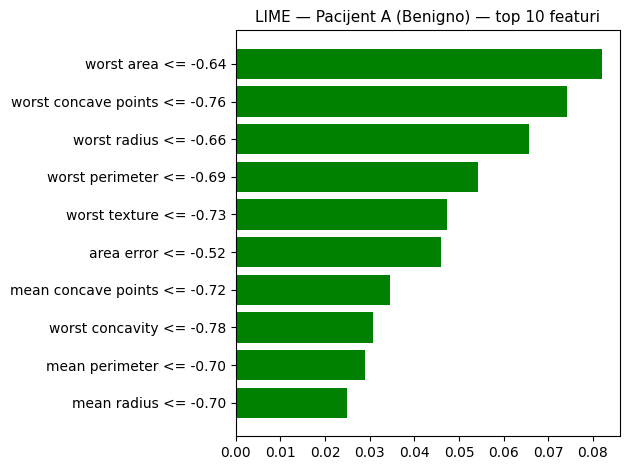

LIME objašnjenje za Pacijenta A:
  worst area <= -0.64                            +0.0820  ↑ benigno
  worst concave points <= -0.76                  +0.0741  ↑ benigno
  worst radius <= -0.66                          +0.0657  ↑ benigno
  worst perimeter <= -0.69                       +0.0543  ↑ benigno
  worst texture <= -0.73                         +0.0474  ↑ benigno
  area error <= -0.52                            +0.0461  ↑ benigno
  mean concave points <= -0.72                   +0.0345  ↑ benigno
  worst concavity <= -0.78                       +0.0308  ↑ benigno
  mean perimeter <= -0.70                        +0.0290  ↑ benigno
  mean radius <= -0.70                           +0.0249  ↑ benigno


In [16]:
# LIME objašnjenje za Pacijenta A (benigno)
exp_a = lime_explainer.explain_instance(
    data_row       = X_test_s.iloc[tp_benigno_idx].values,
    predict_fn     = rf.predict_proba,
    num_features   = 10,   # prikaži top 10 featuri
    num_samples    = 5000  # broj perturbacija
)

# Matplotlib vizualizacija
fig = exp_a.as_pyplot_figure(label=1)  # label=1 → benigno klasa
plt.title('LIME — Pacijent A (Benigno) — top 10 featuri', fontsize=11)
plt.tight_layout()
plt.show()

print("LIME objašnjenje za Pacijenta A:")
for feature, weight in exp_a.as_list(label=1):
    smjer = "↑ benigno" if weight > 0 else "↓ benigno (rizik maligno)"
    print(f"  {feature:45s}  {weight:+.4f}  {smjer}")

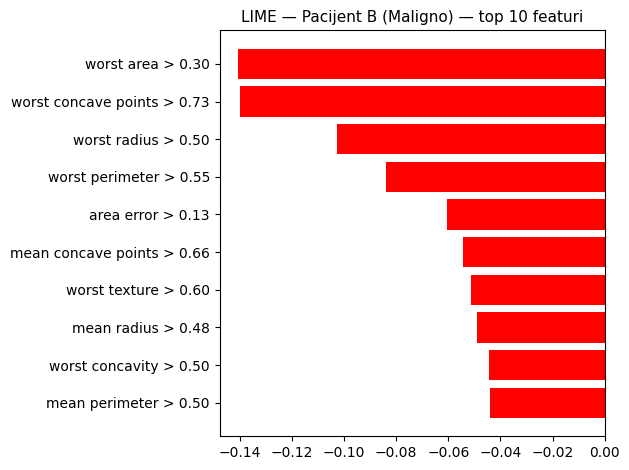

In [17]:
# LIME objašnjenje za Pacijenta B (maligno)
exp_b = lime_explainer.explain_instance(
    data_row       = X_test_s.iloc[tp_maligno_idx].values,
    predict_fn     = rf.predict_proba,
    num_features   = 10,
    num_samples    = 5000
)

fig = exp_b.as_pyplot_figure(label=1)
plt.title('LIME — Pacijent B (Maligno) — top 10 featuri', fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. SHAP vs. LIME — direktna usporedba

In [18]:
def usporedi_shap_lime(idx, naziv, shap_vals, lime_exp,
                       feature_names, top_n=10):
    """Vizualizuje SHAP i LIME objašnjenja za isti primjer."""

    # SHAP top featuri
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap':    shap_vals[idx]
    }).reindex(pd.Series(np.abs(shap_vals[idx]),
               index=feature_names).nlargest(top_n).index)

    # LIME top featuri
    lime_dict  = dict(lime_exp.as_list(label=1))
    lime_df    = pd.DataFrame(
        [(k, v) for k, v in lime_dict.items()],
        columns=['feature', 'lime']
    ).set_index('feature')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # SHAP
    boje_s = ['coral' if v > 0 else 'steelblue' for v in shap_df['shap']]
    ax1.barh(shap_df['feature'], shap_df['shap'], color=boje_s)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.set_title(f'SHAP — {naziv}')
    ax1.set_xlabel('SHAP vrijednost (doprinos predikciji Benigno)')
    ax1.grid(True, alpha=0.3, axis='x')

    # LIME
    boje_l = ['coral' if v > 0 else 'steelblue' for v in lime_df['lime']]
    ax2.barh(lime_df.index, lime_df['lime'], color=boje_l)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_title(f'LIME — {naziv}')
    ax2.set_xlabel('LIME koeficijent (lokalni linearni model)')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()


usporedi_shap_lime(
    tp_benigno_idx, 'Pacijent A (Benigno)',
    shap_benigno, exp_a,
    list(cancer.feature_names)
)

usporedi_shap_lime(
    tp_maligno_idx, 'Pacijent B (Maligno)',
    shap_benigno, exp_b,
    list(cancer.feature_names)
)

print("Ključne razlike SHAP vs LIME:")
print("  SHAP: matematički garancija aditivnosti, konzistentnost, globalna koherentnost")
print("  LIME: brži za kompleksne modele, fleksibilan, ali manje stabilan")
print("  Ako se slažu → objašnjenje je pouzdano")
print("  Ako se razlikuju → treba istraživati zašto (moguća nelinearnost ili nestabilnost)")

ValueError: Per-column arrays must each be 1-dimensional

---
## 9. SHAP za neuralnu mrežu

Do sada smo koristili TreeExplainer koji je specifičan za stabla. Za neuronske mreže koristimo **GradientExplainer** ili **KernelExplainer**.

In [19]:
# Treniramo MLP na istom datasetu
nn_model = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model.fit(
    X_train_s.values, y_train,
    epochs=50, batch_size=16,
    validation_split=0.15,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
    verbose=0
)

y_pred_nn = (nn_model.predict(X_test_s.values, verbose=0) > 0.5).astype(int).flatten()
f1_nn     = f1_score(y_test, y_pred_nn, average='weighted')
print(f"MLP — F1: {f1_nn:.4f}")

MLP — F1: 0.9737


SHAP vrijednosti za NN: (50, 30)


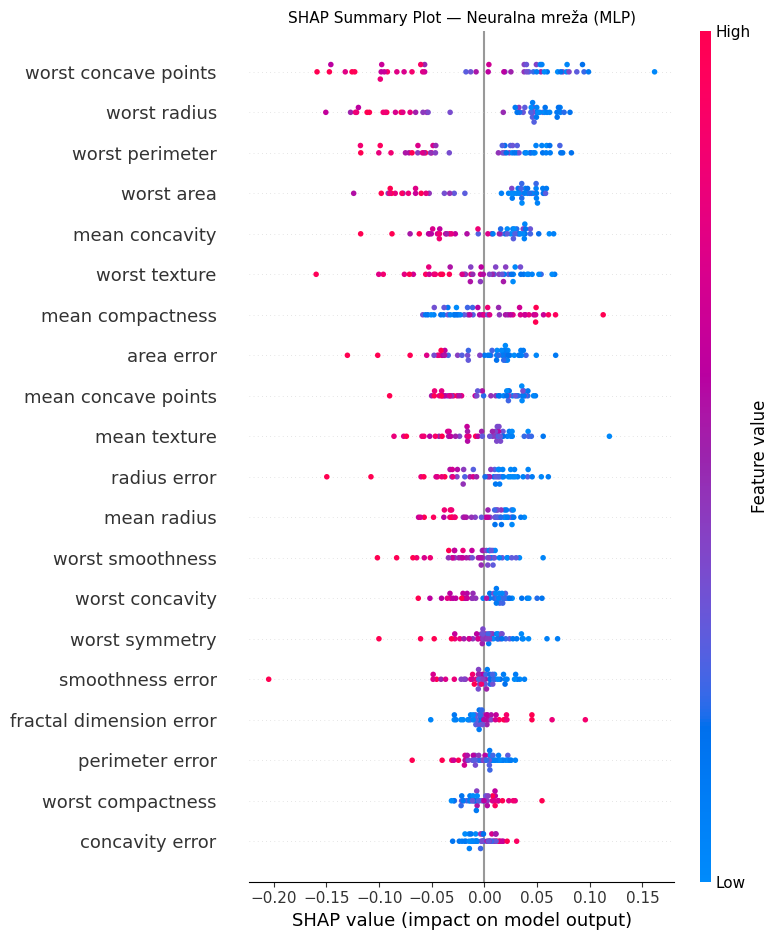

In [20]:
# GradientExplainer za neuralnu mrežu
# Koristi gradijente da odredi doprinos featuri
background = X_train_s.values[:100]  # reprezentativni background dataset

nn_explainer   = shap.GradientExplainer(nn_model, background)
shap_nn_values = nn_explainer.shap_values(X_test_s.values[:50])  # prvih 50 test uzoraka

# GradientExplainer vraća listu ili array ovisno o verziji
if isinstance(shap_nn_values, list):
    shap_nn = shap_nn_values[0]
else:
    shap_nn = shap_nn_values

# Ako je 3D (što se ponekad desi), uzmi prvu dimenziju
if shap_nn.ndim == 3:
    shap_nn = shap_nn[:, :, 0]

print(f"SHAP vrijednosti za NN: {shap_nn.shape}")

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_nn,
    X_test_s.iloc[:50],
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Neuralna mreža (MLP)', fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
# Usporedba: koji su featuri važni za RF vs. MLP?
shap_imp_rf = pd.Series(
    np.abs(shap_benigno).mean(axis=0),
    index=cancer.feature_names
).sort_values(ascending=False).head(10)

shap_imp_nn = pd.Series(
    np.abs(shap_nn).mean(axis=0),
    index=cancer.feature_names
).sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

shap_imp_rf.sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title(f'Random Forest (F1={f1_rf:.3f})\nTop 10 SHAP featuri')
ax1.set_xlabel('Mean |SHAP|')

shap_imp_nn.sort_values().plot(kind='barh', ax=ax2, color='coral')
ax2.set_title(f'MLP (F1={f1_nn:.3f})\nTop 10 SHAP featuri')
ax2.set_xlabel('Mean |SHAP|')

plt.suptitle('Isti dataset, isti featuri — različiti modeli, različita objašnjenja!', fontsize=11)
plt.tight_layout()
plt.show()

# Preklapanje
zajednicki = set(shap_imp_rf.index) & set(shap_imp_nn.index)
print(f"Zajednički top-10 featuri u oba modela: {len(zajednicki)}/10")
print(f"  {sorted(zajednicki)}")
print("\nAko se top featuri podudaraju → robustno objašnjenje neovisno o modelu.")
print("Ako se razlikuju → modeli su naučili različite obrasce.")

ValueError: Data must be 1-dimensional, got ndarray of shape (30, 2) instead

---
## 10. Šta smo naučili danas

| Koncept | Šta znači |
|---|---|
| **XAI** | Metode za objašnjenje odluka ML modela |
| **Globalno objašnjenje** | Koji featuri su općenito važni za model |
| **Lokalno objašnjenje** | Zašto je model donio OVU konkretnu odluku |
| **SHAP** | Shapley vrijednosti — pravedna raspodjela doprinosa (teorija igara) |
| **Bazna vrijednost** | Prosječna predikcija — polazna tačka svih SHAP objašnjenja |
| **Summary Plot** | Globalni pregled SHAP vrijednosti za sve uzorke i featuri |
| **Waterfall Plot** | Lokalni prikaz — kako featuri grade predikciju za jedan uzorak |
| **Force Plot** | Kompaktni lokalni prikaz — crveno=povećava, plavo=smanjuje |
| **Dependence Plot** | Interakcija između dva featuri |
| **LIME** | Lokalna linearna aproksimacija crne kutije |
| **TreeExplainer** | Brzi SHAP za stabla (RF, XGBoost) |
| **GradientExplainer** | SHAP za neuronske mreže |

---
##  ZADATAK — 4 BODA


### Šta trebate uraditi:

1. **Pronađite klasifikacijski dataset** na [kaggle.com](https://kaggle.com):
   - Preporučeno: `Heart Disease UCI`, `Diabetes Dataset`, `Titanic`, `Credit Card Approval`, `Employee Attrition`
   - Mora imati numeričke i/ili kategoričke featuri i binarni target
   - Kategoričke featuri enkodujte s `pd.get_dummies()` ili `LabelEncoder`

2. **Istrenirajte RandomForest** i prikažite:
   - F1 score i classification report
   - SHAP Summary Plot (globalni)
   - SHAP Waterfall za 2 konkretna primjera (jedan iz svake klase)

3. **LIME objašnjenje** za ista 2 primjera

4. **Napišite komentar** (markdown ćelija):
   - Koji su top-3 featuri prema SHAP-u i šta to znači za vaš problem?
   - Slažu li se SHAP i LIME za vaša 2 primjera?
   - Zamislite da ste doktor / bankarski savjetnik / HR menadžer koji koristi ovaj model — kako biste koristili ova objašnjenja?



### Bodovanje:
- **1 bod** — RF treniran, SHAP Summary Plot i Waterfall za 2 primjera
- **1.5 bod** — LIME za ista 2 primjera, vlastiti dataset
- **1.5 bod** — Komentar koji odgovara na sva tri pitanja — posebno treće

